In [1]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity



import os
import glob
import json
import numpy as np
#import tensorflow as tf
import sys

In [2]:
import sys
#fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

old_save_path = f'{save_path}old/'
if old_save_path  not in sys.path:
    sys.path.append(old_save_path )

n_sub_tuning_path = f'{save_path}old/n_sub_tuning/'
if n_sub_tuning_path  not in sys.path:
    sys.path.append(n_sub_tuning_path)

ncells_tuning_path = f'{save_path}old/ncells_tuning/'
if ncells_tuning_path  not in sys.path:
    sys.path.append(ncells_tuning_path)

all_functions_path = f'{fixed_path}CellCNN/New running ipynb/Fixed/'
if all_functions_path  not in sys.path:
    sys.path.append(all_functions_path)


In [3]:
decache_files = ['All_fixed_functions' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

from All_fixed_functions import extract_num, load_ncells_tuning_steps, flatten, load_nsub_tuning_steps, retrieve_nsub_models_names

All_fixed_functions non trovato nella cache


In [6]:
import os
'''
#percorso = "/percorso/desiderato"

# Ottieni solo i nomi delle cartelle
n_sub_cartelle = [
    nome for nome in os.listdir(n_sub_tuning_path )
    if os.path.isdir(os.path.join(n_sub_tuning_path , nome))
]


def extract_num(folder_name):
    if 'model_' in folder_name:
        return folder_name
     
nsub_models = [
    extract_num(model) for model in n_sub_cartelle 
    if extract_num(model) is not None
]

#models = ['model_1','model_2', 'model_3']
print(nsub_models)
''' 
nsub_models = retrieve_nsub_models_names(n_sub_tuning_path)
print(nsub_models)

['model_1', 'model_14_11_0.0001%_1', 'model_14_11_0.001%_1', 'model_2']


In [7]:
import os

#percorso = "/percorso/desiderato"
''' 
# Ottieni solo i nomi delle cartelle
ncells_cartelle = [
    nome for nome in os.listdir(ncells_tuning_path )
    if os.path.isdir(os.path.join(ncells_tuning_path , nome))
]
   
def extract_num(folder_name):
    if 'model_' in folder_name:
        return folder_name
      
ncells_models = [
    extract_num(model) for model in ncells_cartelle 
    if extract_num(model) is not None
]

#models = ['model_1','model_2', 'model_3']
print(ncells_models)
''' 
ncells_models = retrieve_nsub_models_names(ncells_tuning_path)
print(ncells_models)

['model_14_11_0.0001%_1', 'model_14_11_0.001%_1', 'model_2']


## ncells tuning plots

In [8]:
'''    
def load_ncells_tuning_steps(ncells_tuning_path, mod):
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step1_acc.json', "r", encoding="utf-8") as f:
            ncells_step1_acc = json.load(f)
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step1_f1.json', "r", encoding="utf-8") as f:
            ncells_step1_f1 = json.load(f)
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step1_x_axis.json', "r", encoding="utf-8") as f:
            ncells_step1_x_axis = json.load(f)

    """step 2"""
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step2_acc.json', "r", encoding="utf-8") as f:
            ncells_step2_acc = json.load(f)
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step2_f1.json', "r", encoding="utf-8") as f:
            ncells_step2_f1 = json.load(f)
    with open(f'{ncells_tuning_path}{ncells_models[mod]}/ncells_step2_x_axis.json', "r", encoding="utf-8") as f:
            ncells_step2_x_axis = json.load(f)

    return ncells_step1_acc, ncells_step1_f1, ncells_step1_x_axis, ncells_step2_acc, ncells_step2_f1, ncells_step2_x_axis
'''    
mod = 1
cell_model = ncells_models[mod]
        
ncells_step1_acc, ncells_step1_f1, ncells_step1_x_axis, ncells_step2_acc, ncells_step2_f1, ncells_step2_x_axis = load_ncells_tuning_steps(ncells_tuning_path, cell_model)

print(ncells_step1_acc, ncells_step1_f1, ncells_step1_x_axis, ncells_step2_acc, ncells_step2_f1, ncells_step2_x_axis)
print('')
print(ncells_step1_acc, ncells_step1_f1, ncells_step1_x_axis)

print(len(ncells_step1_f1))

[[0.7333333333333333, 1.0, 1.0, 0.9333333333333333, 0.8], [0.8666666666666667, 0.7333333333333333, 0.8, 1.0, 0.6666666666666666], [0.8, 0.8666666666666667, 0.7333333333333333, 0.8666666666666667, 1.0], [0.9333333333333333, 0.8, 0.7333333333333333, 0.7333333333333333, 1.0], [0.9333333333333333, 1.0, 0.8666666666666667, 0.8, 1.0], [0.8, 0.8, 0.7333333333333333, 0.8, 0.8666666666666667], [1.0, 0.9333333333333333, 0.8, 0.8, 0.8666666666666667], [0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.8666666666666667, 0.8666666666666667], [0.8, 0.7333333333333333, 0.8, 0.7333333333333333, 0.8], [0.8666666666666667, 0.7333333333333333, 0.6, 0.8666666666666667, 0.9333333333333333]] [[0.5, 1.0, 1.0, 0.9090909090909091, 0.6666666666666666], [0.8, 0.5, 0.6666666666666666, 1.0, 0.2857142857142857], [0.8, 0.8, 0.5, 0.8571428571428571, 1.0], [0.9090909090909091, 0.6666666666666666, 0.5, 0.5, 1.0], [0.9090909090909091, 1.0, 0.8, 0.6666666666666666, 1.0], [0.6666666666666666, 0.666666666666666

10
10


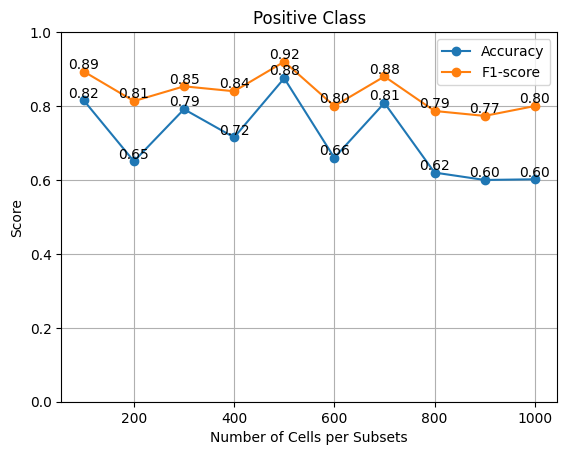

In [9]:
ncells_step1_f1 = [np.mean(f1_list) for f1_list in ncells_step1_f1]
ncells_step1_acc = [np.mean(acc_list) for acc_list in ncells_step1_acc]
print(len(ncells_step1_f1))
print(len(ncells_step1_acc))

ncells_step1_f1 = flatten(ncells_step1_f1)
ncells_step1_acc = flatten(ncells_step1_acc)


# --- Your Plotting Code ---
plt.plot(ncells_step1_x_axis, ncells_step1_f1, marker='o', label='Accuracy')
plt.plot(ncells_step1_x_axis, ncells_step1_acc, marker='o', label='F1-score')

# --- Add Labels ---
# 1. Add labels for the Accuracy plot
for x, y in zip(ncells_step1_x_axis, ncells_step1_acc):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

# 2. Add labels for the F1-score plot
for x, y in zip(ncells_step1_x_axis, ncells_step1_f1):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.ylim(0,1)
# --- Finalize Plot ---
plt.legend()
plt.grid(True) # Optional, but helps readability
plt.title('Positive Class')
plt.xlabel("Number of Cells per Subsets") # Optional
plt.ylabel("Score") # Optional
plt.show()

In [10]:
'''
def flatten(nested):
    if nested is None:
        return []
    if not isinstance(nested, (list, tuple)):
        return [nested]
    nested = list(nested)
    result = []
    for item in nested:
        result.extend(flatten(item))
    return result
'''

'\ndef flatten(nested):\n    if nested is None:\n        return []\n    if not isinstance(nested, (list, tuple)):\n        return [nested]\n    nested = list(nested)\n    result = []\n    for item in nested:\n        result.extend(flatten(item))\n    return result\n'

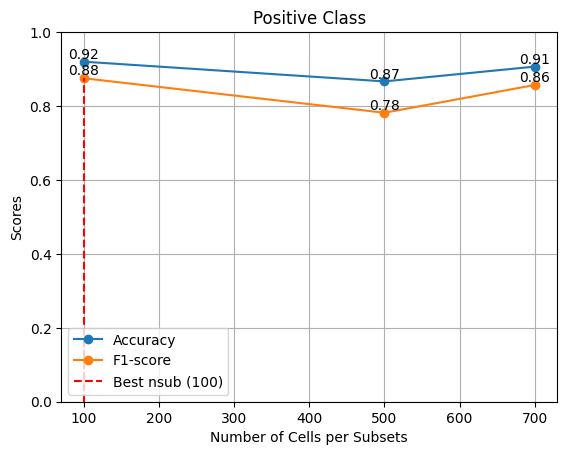

In [11]:

acc_ncells_3_means = [np.mean(acc) for acc in ncells_step2_acc]
f1_ncells_3_means = [np.mean(f1) for f1 in ncells_step2_f1]

max_idx = f1_ncells_3_means.index(np.max(f1_ncells_3_means))

# --- Your Plotting Code ---
plt.plot(ncells_step2_x_axis, acc_ncells_3_means, marker='o', label='Accuracy')
plt.plot(ncells_step2_x_axis, f1_ncells_3_means, marker='o', label='F1-score')

# --- Add Labels ---
# 1. Add labels for the Accuracy plot
for x, y in zip(ncells_step2_x_axis, acc_ncells_3_means):
    # f"{y:.2f}" formats the number to 2 decimal places
    # ha='center' centers the text horizontally
    # va='bottom' places the text just above the (x,y) point
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

# 2. Add labels for the F1-score plot
for x, y in zip(ncells_step2_x_axis, f1_ncells_3_means):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')
    
plt.vlines(x = ncells_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_3_means), color='red', linestyle='--', label=f'Best nsub ({ncells_step2_x_axis[max_idx]})')

plt.ylim(0,1)
# --- Finalize Plot ---
plt.legend()
plt.grid(True) # Optional, but helps readability
plt.title('Positive Class')
plt.xlabel("Number of Cells per Subsets") # Optional
plt.ylabel("Scores") # Optional
plt.show()

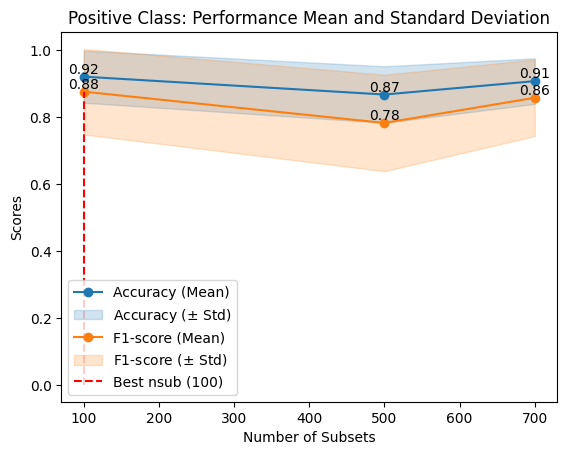

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate Mean and Standard Deviation (Std)
acc_ncells_3_means = [np.mean(acc) for acc in ncells_step2_acc]
f1_ncells_3_means = [np.mean(f1) for f1 in ncells_step2_f1]
acc_ncells_3_stds = [np.std(acc) for acc in ncells_step2_acc]
f1_ncells_3_stds = [np.std(f1) for f1 in ncells_step2_f1]

max_idx = acc_ncells_3_means.index(np.max(acc_ncells_3_means))



# Plot Accuracy Mean
plt.plot(ncells_step2_x_axis, acc_ncells_3_means, marker='o', label='Accuracy (Mean)', color='C0')
# Plot Accuracy Std as a shaded region
acc_upper = np.array(acc_ncells_3_means) + np.array(acc_ncells_3_stds)
acc_lower = np.array(acc_ncells_3_means) - np.array(acc_ncells_3_stds)
plt.fill_between(ncells_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')

# Plot F1-score Mean
plt.plot(ncells_step2_x_axis, f1_ncells_3_means , marker='o', label='F1-score (Mean)', color='C1')
# Plot F1-score Std as a shaded region
f1_upper = np.array(f1_ncells_3_means ) + np.array(f1_ncells_3_stds)
f1_lower = np.array(f1_ncells_3_means ) - np.array(f1_ncells_3_stds)
plt.fill_between(ncells_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

for x, y in zip(ncells_step2_x_axis, acc_ncells_3_means):
    # f"{y:.2f}" formats the number to 2 decimal places
    # ha='center' centers the text horizontally
    # va='bottom' places the text just above the (x,y) point
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

# 2. Add labels for the F1-score plot
for x, y in zip(ncells_step2_x_axis, f1_ncells_3_means):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')
    
plt.vlines(x = ncells_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_3_means ), color='red', linestyle='--', label=f'Best nsub ({ncells_step2_x_axis[max_idx]})')
#plt.ylim(0,1)
# ... (Keep label and finalization code) ...
plt.title('Positive Class: Performance Mean and Standard Deviation')
plt.xlabel("Number of Subsets")
plt.ylabel("Scores")
plt.legend()
plt.show()

## nsub tuning plots

In [13]:
'''    
def load_nsub_tuning_steps(n_sub_tuning_path, mod):
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_1_acc.json', "r", encoding="utf-8") as f:
            n_sub_step1_acc = json.load(f)
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_1_f1.json', "r", encoding="utf-8") as f:
            n_sub_step1_f1 = json.load(f)
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_1_x_axis.json', "r", encoding="utf-8") as f:
            n_sub_step1_x_axis = json.load(f)

    """step 2"""
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_2_acc.json', "r", encoding="utf-8") as f:
            n_sub_step2_acc = json.load(f)
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_2_f1.json', "r", encoding="utf-8") as f:
            n_sub_step2_f1 = json.load(f)
    with open(f'{n_sub_tuning_path}{n_sub_models[mod]}/step_2_x_axis.json', "r", encoding="utf-8") as f:
            n_sub_step2_x_axis = json.load(f)

    return n_sub_step1_acc, n_sub_step1_f1, n_sub_step1_x_axis, n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis
'''     
mod = 1
sub_model = nsub_models[mod]
n_sub_step1_acc, n_sub_step1_f1, n_sub_step1_x_axis, n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis = load_nsub_tuning_steps(n_sub_tuning_path, sub_model)

print(n_sub_step1_acc, n_sub_step1_f1, n_sub_step1_x_axis, n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis)
print('')
print( n_sub_step2_acc, n_sub_step2_f1, n_sub_step2_x_axis)

[0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.64, 0.6, 0.6, 0.6, 0.6, 0.64, 0.6, 0.64, 0.6, 0.6, 0.64, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.64, 0.64, 0.6, 0.6, 0.6, 0.64, 0.72, 0.64, 0.6, 0.6, 0.64] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.18181818181818182, 0.0, 0.0, 0.0, 0.0, 0.18181818181818182, 0.0, 0.18181818181818182, 0.0, 0.0, 0.18181818181818182, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.18181818181818182, 0.18181818181818182, 0.0, 0.0, 0.0, 0.18181818181818182, 0.46153846153846156, 0.18181818181818182, 0.0, 0.0, 0.18181818181818182] [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500, 520, 540, 560, 580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800, 820, 840, 860, 880, 900, 920, 940, 960, 980, 1000] [[0.6, 0.6, 0.64, 0.68, 0.6], [0.6, 0.96, 0.64, 0.6, 0.6], [0.6, 1.0, 0.68, 0.64

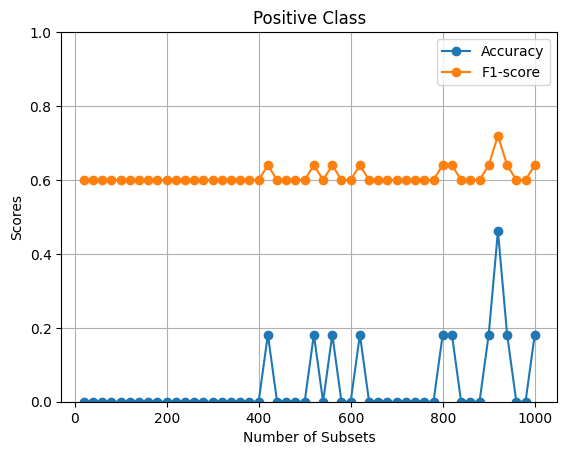

In [14]:
n_sub_step1_f1 = flatten(n_sub_step1_f1)
n_sub_step1_acc = flatten(n_sub_step1_acc)
# --- Your Plotting Code ---
plt.plot(n_sub_step1_x_axis, n_sub_step1_f1, marker='o', label='Accuracy')
plt.plot(n_sub_step1_x_axis, n_sub_step1_acc, marker='o', label='F1-score')

'''
# --- Add Labels ---
# 1. Add labels for the Accuracy plot
for x, y in zip(n_sub_step1_x_axis, n_sub_step1_acc):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

# 2. Add labels for the F1-score plot
for x, y in zip(n_sub_step1_x_axis, n_sub_step1_f1):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')
'''
plt.ylim(0,1)
# --- Finalize Plot ---
plt.legend()
plt.grid(True) # Optional, but helps readability
plt.title('Positive Class')
plt.xlabel("Number of Subsets") # Optional
plt.ylabel("Scores") # Optional
plt.show()

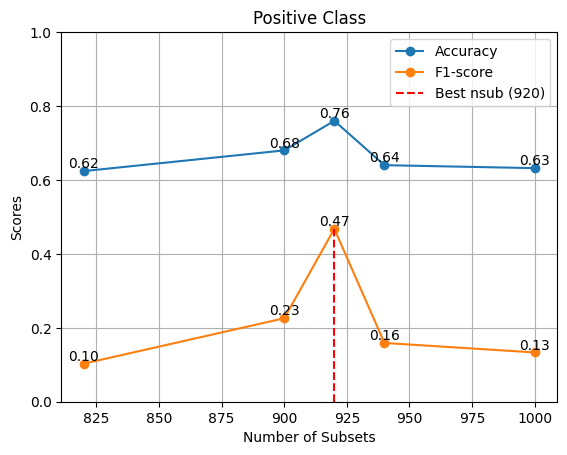

In [15]:

acc_5_means = [np.mean(acc) for acc in  n_sub_step2_acc]
f1_5_means = [np.mean(f1) for f1 in n_sub_step2_f1]
max_idx = f1_5_means.index(np.max(f1_5_means))
# --- Your Plotting Code ---
plt.plot(n_sub_step2_x_axis, acc_5_means, marker='o', label='Accuracy')
plt.plot(n_sub_step2_x_axis, f1_5_means, marker='o', label='F1-score')

# --- Add Labels ---
# 1. Add labels for the Accuracy plot
for x, y in zip(n_sub_step2_x_axis, acc_5_means):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

# 2. Add labels for the F1-score plot
for x, y in zip(n_sub_step2_x_axis, f1_5_means):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
plt.ylim(0,1)
# --- Finalize Plot ---
plt.legend()
plt.grid(True) # Optional, but helps readability
plt.title('Positive Class')
plt.xlabel("Number of Subsets") # Optional
plt.ylabel("Scores") # Optional
plt.show()


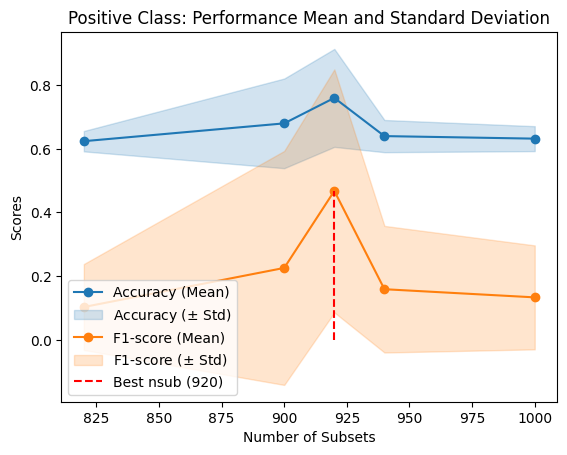

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate Mean and Standard Deviation (Std)
acc_5_means = [np.mean(acc) for acc in n_sub_step2_acc]
f1_5_means = [np.mean(f1) for f1 in n_sub_step2_f1]
acc_5_stds = [np.std(acc) for acc in n_sub_step2_acc]
f1_5_stds = [np.std(f1) for f1 in n_sub_step2_f1]

max_idx = f1_5_means.index(np.max(f1_5_means))


# Plot Accuracy Mean
plt.plot(n_sub_step2_x_axis, acc_5_means, marker='o', label='Accuracy (Mean)', color='C0')
# Plot Accuracy Std as a shaded region
acc_upper = np.array(acc_5_means) + np.array(acc_5_stds)
acc_lower = np.array(acc_5_means) - np.array(acc_5_stds)
plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')

# Plot F1-score Mean
plt.plot(n_sub_step2_x_axis, f1_5_means, marker='o', label='F1-score (Mean)', color='C1')
# Plot F1-score Std as a shaded region
f1_upper = np.array(f1_5_means) + np.array(f1_5_stds)
f1_lower = np.array(f1_5_means) - np.array(f1_5_stds)
plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
#plt.ylim(0,1)
# ... (Keep label and finalization code) ...
plt.title('Positive Class: Performance Mean and Standard Deviation')
plt.xlabel("Number of Subsets")
plt.ylabel("Scores")
plt.legend()
plt.show()